## Day 4 — EDA Part 1: Distributions & Outliers 

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

### task1: Load a provided real dataset and produce a histogram for each numeric variable.

In [2]:
df = pd.read_csv('Students/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


['math score', 'reading score', 'writing score']


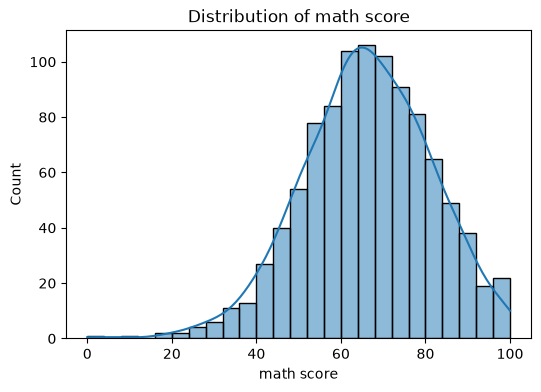

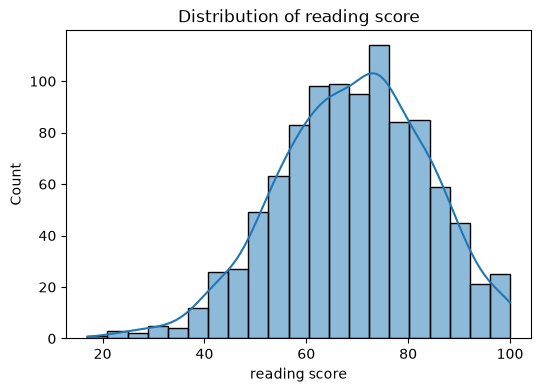

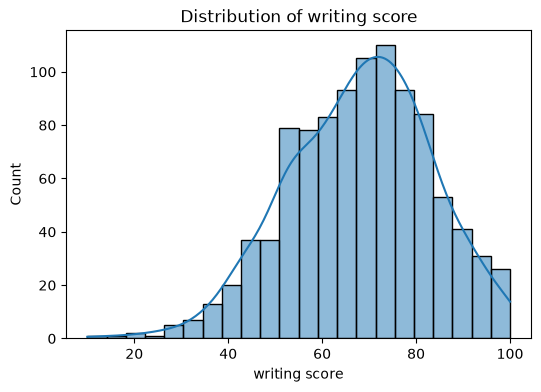

In [3]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print(numeric_cols)

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### Distribution Analysis: Writing, Reading & Math Scores

All three subjects show a **left-skewed** distribution — scores cluster 
around 60-85 with a longer tail toward lower values.

- **Writing:** peaks ~70-75, tail of low scorers below 40
- **Reading:** similar shape, slightly more symmetric
- **Math:** strongest skew, sharper tail toward 0 — more low scorers

Since skew makes mean and median diverge, **median** is the more reliable 
"typical value" here. The similar shapes across subjects suggest scores 
are correlated — worth checking in bivariate analysis next.

### task2: Produce a box plot for the key numeric variables and identify any outliers visually.

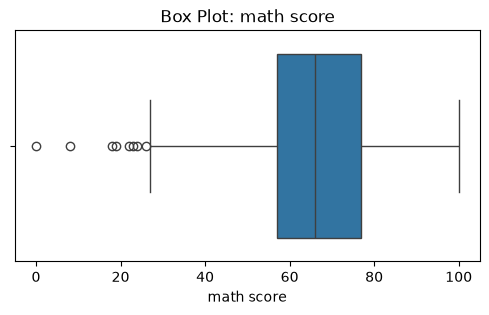

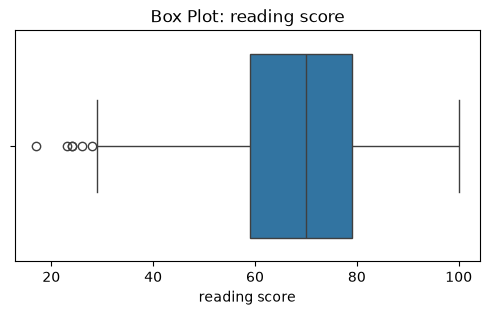

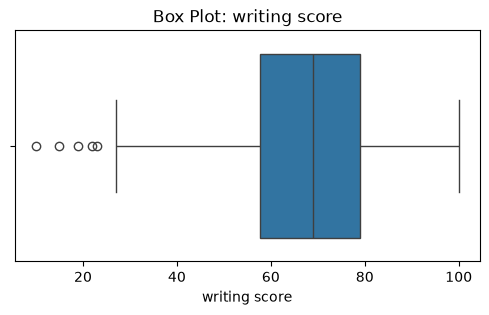

In [4]:
key_numeric = ['math score', 'reading score', 'writing score']

for col in key_numeric:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot: {col}")
    plt.show()

### Box Plot Findings: Writing, Reading & Math Scores

All three subjects show **outliers only on the low end** (no high-end 
outliers, max stays at 100) — consistent with the left-skew seen earlier.

- **Writing:** outliers below ~27, lowest ~10-15
- **Reading:** outliers below ~28, lowest ~17
- **Math:** most extreme — outliers down to **0**

**Decision:** Keep them — these are plausible real low scores, not errors, 
and likely represent a struggling subgroup worth exploring further (e.g. 
link to `test preparation course` or `lunch`).

### task3:  Apply the IQR method in code to flag outliers in at least one column, and decide (with justification) how to handle them.

In [5]:
col = 'math score'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print(f"Number of outliers in {col}: {len(outliers)}")
print(outliers[[col]])

Q1: 57.0, Q3: 77.0, IQR: 20.0
Lower bound: 27.0, Upper bound: 107.0
Number of outliers in math score: 8
     math score
17           18
59            0
145          22
338          24
466          26
787          19
842          23
980           8


### Decision & Justification: `math score` Outliers

IQR flagged **8 outliers**, all below the lower bound (27.0), ranging 
from 0-26. These are plausible real scores (not errors), consistent with 
the left-skew already seen.

**Decision:** Keep them — they represent real low performers, worth 
exploring in bivariate analysis (e.g. link to `test preparation course` 
or `lunch`) rather than removing.

### task4: Produce a count plot for each categorical variable and note any class imbalance.

In [6]:
df.head()   

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


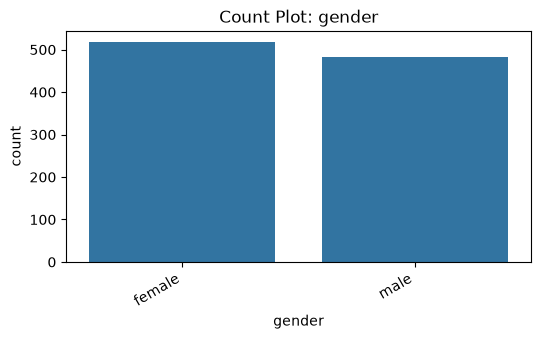

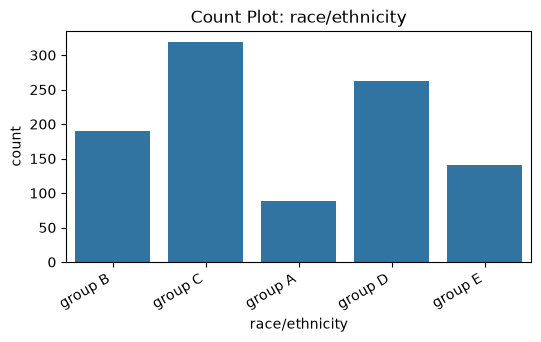

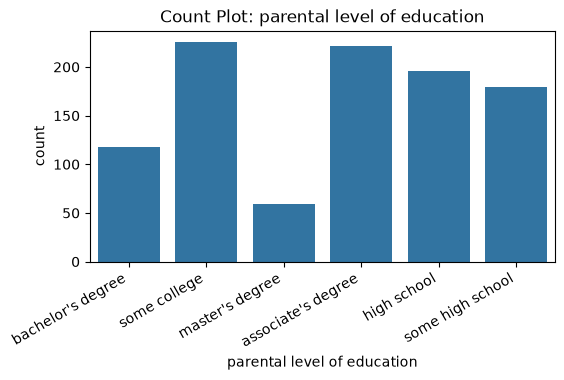

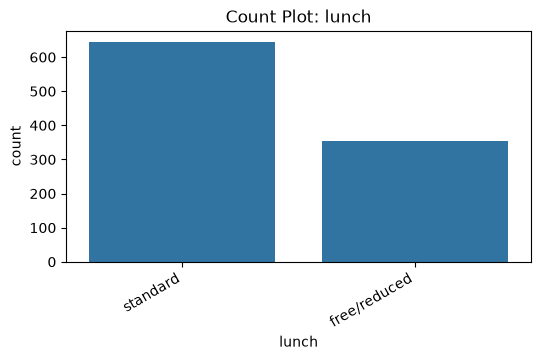

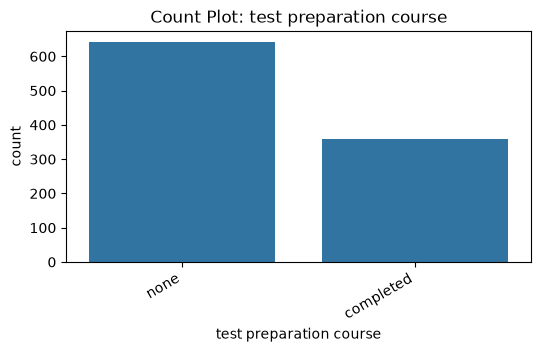

In [7]:
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 
                     'lunch', 'test preparation course']

for col in categorical_cols:
    plt.figure(figsize=(6, 3))
    sns.countplot(data=df, x=col)
    plt.title(f"Count Plot: {col}")
    plt.xticks(rotation=30, ha='right')
    plt.show()

### Count Plot Findings: Categorical Variables

- **gender:** roughly balanced (~510 female, ~480 male) — no imbalance concern.
- **race/ethnicity:** moderate imbalance — `group C` (~320) and `group D` (~260) 
  dominate, while `group A` (~90) is notably underrepresented.
- **parental level of education:** fairly balanced across most categories, 
  though `master's degree` (~60) is much smaller than the rest (~120-225).
- **lunch:** moderate imbalance — `standard` (~645) roughly double `free/reduced` (~355).
- **test preparation course:** moderate imbalance — `none` (~640) nearly double 
  `completed` (~360).

**Overall:** No severe imbalance (no category near 0%), but `race/ethnicity` 
(group A), `parental level of education` (master's degree), `lunch`, and 
`test preparation course` all show meaningful skew. These are worth watching 
in bivariate analysis, since smaller subgroups (e.g. `group A`, `master's 
degree`) will have less statistical power behind any pattern found.